In [1]:
import piplite
await piplite.install(['pandas', 'numpy', 'matplotlib', 'seaborn'])

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# This makes your charts look a bit cleaner
%matplotlib inline 
print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
#loadtables
df_assessments = pd.read_csv('data/assessments.csv')
df_courses = pd.read_csv('data/courses.csv')
df_studentAssessment = pd.read_csv('data/studentAssessment.csv')
df_studentInfo = pd.read_csv('data/studentInfo.csv')
df_studentRegistration = pd.read_csv('data/studentRegistration.csv')
df_vle = pd.read_csv('data/vle.csv') 

#sampledata
df_assessments.head()
df_courses.head()
df_studentAssessment.head()
df_studentInfo.head()
df_studentRegistration.head()
df_vle.head()

,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN
3,546888,AAA,2013J,url,NaN,NaN
4,547035,AAA,2013J,resource,NaN,NaN


In [5]:
# Inspect EACH file
for name, df in {
    'assessments': df_assessments,
    'courses': df_courses,
    'studentAssessment': df_studentAssessment,
    'studentInfo': df_studentInfo,
    'studentRegistration': df_studentRegistration,
    'vle': df_vle
}.items():
    print(f"\n{'='*40}")
    print(f"FILE: {name}")
    print(f"Shape: {df.shape}")       # rows x columns
    print(df.dtypes)                  # column types
    print(df.isnull().sum())          # missing values
    print(df.head(3))                 # first 3 rows


FILE: assessments
Shape: (206, 6)
code_module           object
code_presentation     object
id_assessment          int64
assessment_type       object
date                 float64
weight               float64
dtype: object
code_module           0
code_presentation     0
id_assessment         0
assessment_type       0
date                 11
weight                0
dtype: int64
  code_module code_presentation  id_assessment assessment_type   date  weight
0         AAA             2013J           1752             TMA   19.0    10.0
1         AAA             2013J           1753             TMA   54.0    20.0
2         AAA             2013J           1754             TMA  117.0    20.0

FILE: courses
Shape: (22, 3)
code_module                   object
code_presentation             object
module_presentation_length     int64
dtype: object
code_module                   0
code_presentation             0
module_presentation_length    0
dtype: int64
  code_module code_presentation  module_pres

In [7]:
# Cleaning Data

# 1. studentAssessment: drop 173 unscored rows
df_studentAssessment = df_studentAssessment.dropna(subset=['score'])

# 2. studentInfo: fill missing imd_band + create target variable
df_studentInfo['imd_band'] = df_studentInfo['imd_band'].fillna('Unknown')
df_studentInfo['dropped_out'] = (df_studentInfo['final_result'] == 'Withdrawn').astype(int)

# 3. studentRegistration: clean both date columns
df_studentRegistration = df_studentRegistration.dropna(subset=['date_registration'])
df_studentRegistration['date_unregistration'] = df_studentRegistration['date_unregistration'].fillna(0)

# Confirm
print("studentAssessment nulls:", df_studentAssessment['score'].isnull().sum())       # should be 0
print("studentInfo imd nulls:", df_studentInfo['imd_band'].isnull().sum())            # should be 0
print("registration nulls:", df_studentRegistration['date_registration'].isnull().sum()) # should be 0
print("Dropout rate:", df_studentInfo['dropped_out'].mean().round(2))                 # your key stat

studentAssessment nulls: 0
studentInfo imd nulls: 0
registration nulls: 0
Dropout rate: 0.31


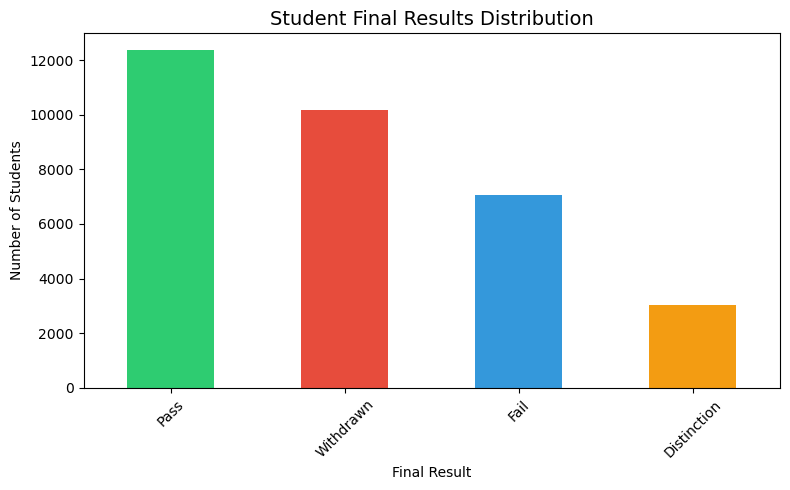

In [10]:
# Overall dropout breakdown
dropout_counts = df_studentInfo['final_result'].value_counts()

plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']
dropout_counts.plot(kind='bar', color=colors)
plt.title('Student Final Results Distribution', fontsize=14)
plt.xlabel('Final Result')
plt.ylabel('Number of Students')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

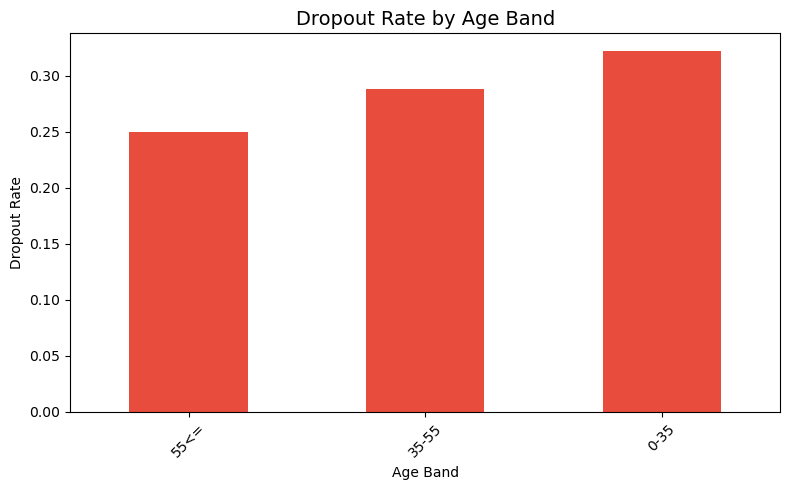

In [11]:
plt.figure(figsize=(8, 5))
df_studentInfo.groupby('age_band')['dropped_out'].mean().sort_values().plot(
    kind='bar', color='#e74c3c')
plt.title('Dropout Rate by Age Band', fontsize=14)
plt.xlabel('Age Band')
plt.ylabel('Dropout Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

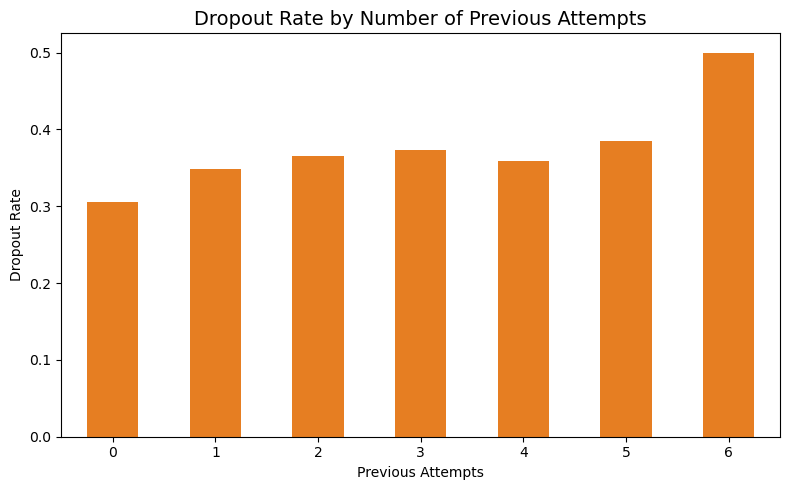

In [12]:
plt.figure(figsize=(8, 5))
df_studentInfo.groupby('num_of_prev_attempts')['dropped_out'].mean().plot(
    kind='bar', color='#e67e22')
plt.title('Dropout Rate by Number of Previous Attempts', fontsize=14)
plt.xlabel('Previous Attempts')
plt.ylabel('Dropout Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

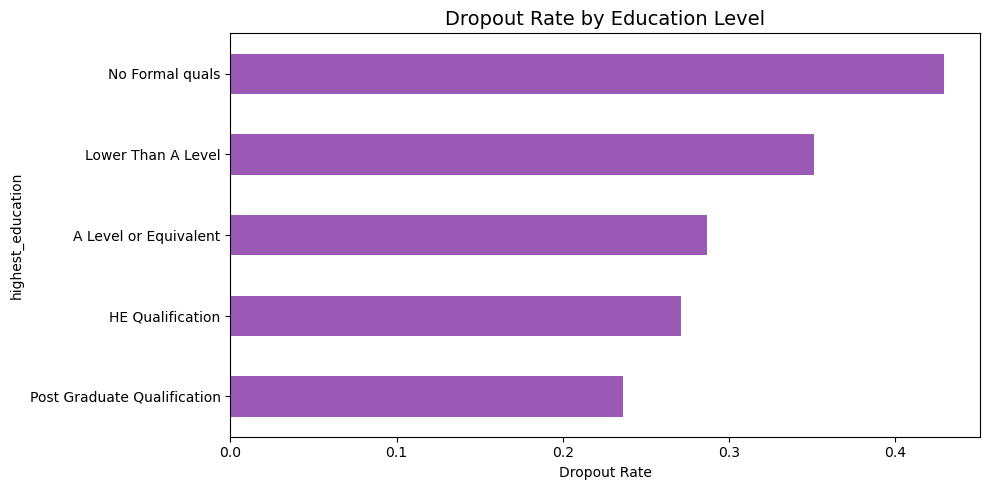

In [13]:
plt.figure(figsize=(10, 5))
edu_dropout = df_studentInfo.groupby('highest_education')['dropped_out'].mean().sort_values()
edu_dropout.plot(kind='barh', color='#9b59b6')
plt.title('Dropout Rate by Education Level', fontsize=14)
plt.xlabel('Dropout Rate')
plt.tight_layout()
plt.show()

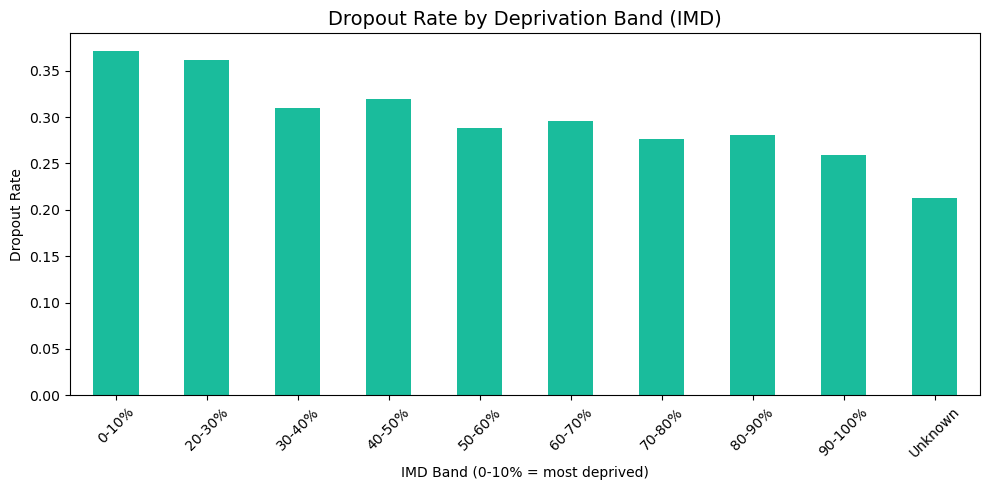

In [14]:
plt.figure(figsize=(10, 5))

# Define correct order for IMD bands
imd_order = ['0-10%','10-20%','20-30%','30-40%','40-50%',
             '50-60%','60-70%','70-80%','80-90%','90-100%','Unknown']

imd_dropout = df_studentInfo.groupby('imd_band')['dropped_out'].mean()
imd_dropout = imd_dropout.reindex(imd_order).dropna()

imd_dropout.plot(kind='bar', color='#1abc9c')
plt.title('Dropout Rate by Deprivation Band (IMD)', fontsize=14)
plt.xlabel('IMD Band (0-10% = most deprived)')
plt.ylabel('Dropout Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()